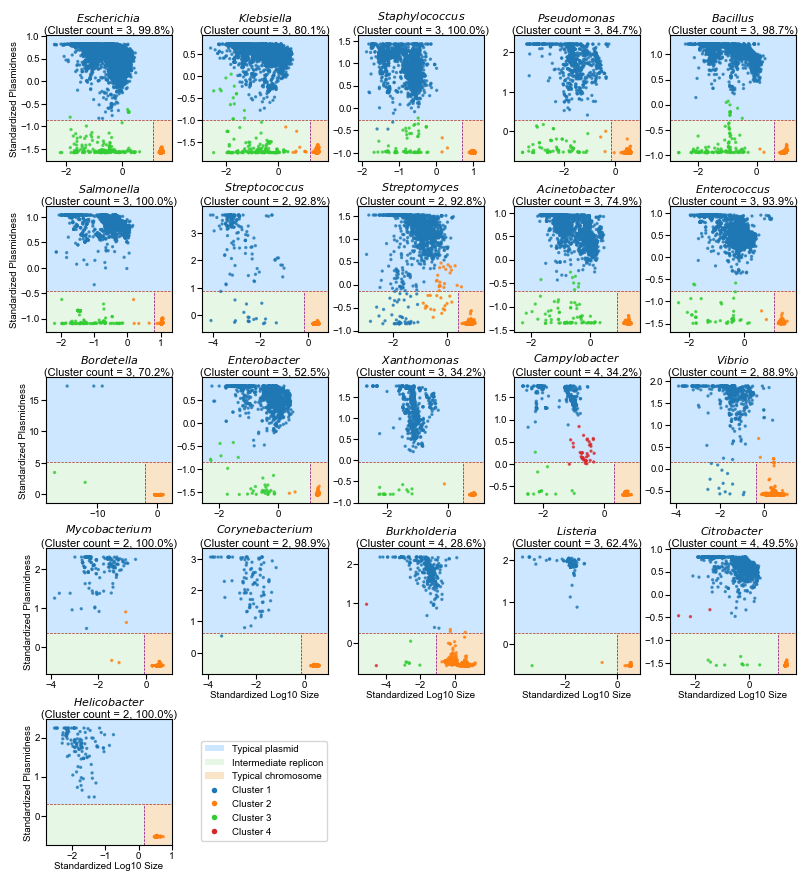

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import os

plasmidness_col = "average plasmid fraction-pident_90"
BASE_FOLDER = '/active-data/analysis_results/chr_pla/genus/recluster_result'
OUTPUT_SUMMARY_CSV = os.path.join(BASE_FOLDER, "genus_bootstrap_summary.csv")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

summary_df = pd.read_csv(OUTPUT_SUMMARY_CSV)
keep_genus = summary_df["genus"].tolist()
n_plots = len(keep_genus)

gap_h = 0.04
gap_v = 0.06
total_cols = 5
fig = plt.figure(figsize=(7.5, 7.5))

w = (1.0 - (total_cols - 1) * gap_h) / total_cols
h = w
expand_ratio = 0.08

color_plasmid = "#cce7ff"
color_intermediate = "#e6f7e6"
color_chromosome = "#f9e4c8"

region_handles = [
    Patch(facecolor=color_plasmid, edgecolor="none", alpha=1.0, label="Typical plasmid"),
    Patch(facecolor=color_intermediate, edgecolor="none", alpha=1.0, label="Intermediate replicon"),
    Patch(facecolor=color_chromosome, edgecolor="none", alpha=1.0, label="Typical chromosome"),
]

cluster_handles = [
    Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.tab10(0), markersize=5, label="Cluster 1"),
    Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.tab10(1), markersize=5, label="Cluster 2"),
    Line2D([], [], marker='o', color='w', markerfacecolor="#32CD32", markersize=5, label="Cluster 3"),  #plt.cm.tab10(2)
    Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.tab10(3), markersize=5, label="Cluster 4"),
]

full_legend_elements = region_handles + cluster_handles

full_rows = n_plots // total_cols
remainder = n_plots % total_cols
i = 0

for genus_name in keep_genus:
    folder = os.path.join(BASE_FOLDER, genus_name)
    cluster_df = pd.read_csv(os.path.join(folder, f"{genus_name}_cluster_result.csv"))
    info = summary_df[summary_df["genus"] == genus_name].iloc[0]

    X = cluster_df[["std_log10_size", "std_plasmidness"]].values
    labels = cluster_df["cluster_label"].values
    std_size_thresh = info["std_size_threshold"]
    std_plasmidness_thresh = info["std_plasmidness_threshold"]
    real_ncls = int(info["real_ncls"])
    real_ncls_ratio = info["repeat_ratio"]

    col_idx = i % total_cols
    row_idx = i // total_cols
    i += 1

    x0 = col_idx * (w + gap_h)
    y0 = 1.0 - h - row_idx * (h + gap_v)
    ax = fig.add_axes([x0, y0, w, h])

    x_raw_min, x_raw_max = X[:,0].min(), X[:,0].max()
    y_raw_min, y_raw_max = X[:,1].min(), X[:,1].max()
    x_span = x_raw_max - x_raw_min
    y_span = y_raw_max - y_raw_min
    xmin = x_raw_min - expand_ratio * x_span
    xmax = x_raw_max + expand_ratio * x_span
    ymin = y_raw_min - expand_ratio * y_span
    ymax = y_raw_max + expand_ratio * y_span

    size_split = std_size_thresh
    threshold = std_plasmidness_thresh

    def get_region_id(x, y):
        if y >= threshold:
            return 0
        elif x < size_split:
            return 1
        else:
            return 2
    point_regions = np.array([get_region_id(pt[0], pt[1]) for pt in X])
    unique_clusters = np.sort(np.unique(labels))
    cluster_info = []
    for cid in unique_clusters:
        mask = labels == cid
        n_points = np.sum(mask)
        reg_counts = np.bincount(point_regions[mask], minlength=3)
        main_region = np.argmax(reg_counts)
        cluster_info.append((-n_points, cid, main_region))
    cluster_info.sort()
    color_map = {}
    region_occupied = set()
    other_color_idx = 3
    for neg_n, cid, main_reg in cluster_info:
        if main_reg not in region_occupied:
            if main_reg == 1:
                color_map[cid] = (*mcolors.to_rgb("#32CD32"), 1.0) #plt.cm.tab10(2)
            elif main_reg == 2:
                color_map[cid] = plt.cm.tab10(1)
            else:
                color_map[cid] = plt.cm.tab10(main_reg)
            region_occupied.add(main_reg)
        else:
            if other_color_idx == 1:
                color_map[cid] = (*mcolors.to_rgb("#32CD32"), 1.0) #plt.cm.tab10(2)
            elif other_color_idx == 2:
                color_map[cid] = plt.cm.tab10(1)
            else:
                color_map[cid] = plt.cm.tab10(other_color_idx)
    point_colors = np.array([color_map[lbl] for lbl in labels])

    ax.scatter(X[:, 0], X[:, 1], c=point_colors, alpha=0.7, s=2, zorder=3)

    rect1 = Rectangle((xmin, threshold), xmax - xmin, ymax - threshold, facecolor=color_plasmid, alpha=1.0, zorder=1)
    ax.add_patch(rect1)
    rect2 = Rectangle((xmin, ymin), size_split - xmin, threshold - ymin, facecolor=color_intermediate, alpha=1.0, zorder=1)
    ax.add_patch(rect2)
    rect3 = Rectangle((size_split, ymin), xmax - size_split, threshold - ymin, facecolor=color_chromosome, alpha=1.0, zorder=1)
    ax.add_patch(rect3)

    ax.plot([std_size_thresh, std_size_thresh], [ymin, std_plasmidness_thresh], color='purple', ls='--', lw=0.5, zorder=2)
    ax.plot([xmin, xmax], [std_plasmidness_thresh, std_plasmidness_thresh], color='brown', ls='--', lw=0.5, zorder=2)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    title_text = r'$\mathit{' + genus_name + r'}$' + '\n' + f'(Cluster count = {real_ncls}, {real_ncls_ratio:.1%})'
    ax.set_title(title_text, pad=1)
    ax.tick_params(axis='both', pad=1)

    if col_idx == 0:
        ax.set_ylabel("Standardized Plasmidness", labelpad=1)
    if remainder > 0 and row_idx == full_rows - 1 and col_idx >= remainder:
        ax.set_xlabel("Standardized Log10 Size", labelpad=1)
    if row_idx == full_rows:
        ax.set_xlabel("Standardized Log10 Size", labelpad=1)

fig.legend(handles=full_legend_elements, loc="lower left", bbox_to_anchor=(0.2, -0.08), frameon=True)
os.chdir("/active-data/analysis_results/chr_pla/genus/figures/scatter_plot")
plt.savefig("S_reclust_results.svg", bbox_inches="tight", transparent=True)
plt.savefig("S_reclust_results.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()